In [1]:
import os
import re
import sys
import glob
import time
import yaml
import intake
import warnings
import numpy as np
import pandas as pd
import scipy as io
import xarray as xr
import matplotlib.dates as mdates

from mpi4py import MPI
from datetime import date, datetime, timedelta
from matplotlib import pyplot as plt
from dask.distributed import Client
from collections import defaultdict
from xarray.coding.times import CFDatetimeCoder

warnings.filterwarnings("ignore") # Suppress warnings for these docs
time_coder = CFDatetimeCoder(use_cftime=True)

In [2]:
os.getcwd()

'/home/581/ob1561'

In [3]:
!ls /g/data/jk72/ob1561

 CERES_EBAF_Ed4.2.1_Subset_200003-202506.nc
 IMOS_DWM-SOTS_BSOPT_20130408T070001Z_SOFS_FV00_SOFS-4-2013-FLNTUS-1802-1m_END-20131028T013633Z_C-20170610T110900Z.nc
 IMOS_DWM-SOTS_BSOPT_20150316T035616Z_SOFS_FV00_SOFS-5-2015-FLNTUS-1802-1m_END-20160420T041408Z_C-20170610T064501Z.nc
 IMOS_DWM-SOTS_COPST_20240316_SOFS_FV00_SOFS-13-2024-Optode-4831-509-1m_END-20250428_C-20250605.nc
 IMOS_DWM-SOTS_CPST_20180808_SOFS_FV01_SOFS-7.5-2018-SBE37-SM-3141-1m_END-20180926_C-20220122.nc
 IMOS_DWM-SOTS_CPST_20240308_SOFS_FV00_SOFS-13-2024-SBE37SM-RS485-03707408-1m_END-20250415_C-20250430.nc
 IMOS_DWM-SOTS_CPST_20240308_SOFS_FV01_SOFS-13-2024-SBE37SM-RS485-03707408-1m_END-20250415_C-20250529.nc
 IMOS_DWM-SOTS_CPST_20240308_SOFS_FV01_SOFS-13-2024-SBE37SM-RS485-03707408-1m_END-20250415_C-20250825.nc
 IMOS_DWM-SOTS_CPST_20240313_SOFS_FV00_SOFS-13-2024-SBE37SM-RS485-03708765-1m_END-20250415_C-20250430.nc
 IMOS_DWM-SOTS_CPST_20240313_SOFS_FV01_SOFS-13-2024-SBE37SM-RS485-03708765-1m_END-20250415_C-20250529.nc

In [4]:
os.chdir("/g/data/jk72/ob1561")
os.getcwd()

'/g/data/jk72/ob1561'

In [5]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/33931/status,
Dashboard: /proxy/33931/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33257,Workers: 0
Dashboard: /proxy/33931/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40589,Total threads: 2
Dashboard: /proxy/40891/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:40567,


In [6]:
PAPA_DIR = "/g/data/jk72/ob1561"

# Test file: latent heat flux at Papa
papa_qlat_path = os.path.join(PAPA_DIR, "qlat50n145w_hr.cdf")

ds_papa_test = xr.open_dataset(papa_qlat_path)
print(ds_papa_test)
print("Data variables:", list(ds_papa_test.data_vars))
print("Coordinates:", list(ds_papa_test.coords))

<xarray.Dataset> Size: 2MB
Dimensions:   (time: 138523, depth: 1, lat: 1, lon: 1)
Coordinates:
  * time      (time) datetime64[ns] 1MB 2010-01-01 ... 2025-10-20T18:00:00
  * depth     (depth) float32 4B 0.0
  * lat       (lat) float32 4B 50.0
  * lon       (lon) float32 4B 215.0
Data variables:
    QL_137    (time, depth, lat, lon) float32 554kB ...
    QQL_5137  (time, depth, lat, lon) float32 554kB ...
Attributes:
    platform_code:                50n145w
    site_code:                    50n145w
    array:                        TAO/TRITON
    Request_for_acknowledgement:  If you use these data in publications or pr...
    Data_Source:                  OCS Project Office/NOAA/PMEL
    OCS:                          Dr. Meghan F. Cronin: Meghan.F.Cronin@noaa.gov
    File_info:                    Contact: Dai.C.McClurg@noaa.gov
    missing_value:                1e+35
    _FillValue:                   1e+35
    CREATION_DATE:                16:32  7-DEC-2025
Data variables: ['QL_137', '

In [7]:
print('Starting ACCESS-OM2 and Papa latent heat flux analysis.')
sys.stdout.flush()

catalog = intake.cat.access_nri
#print(catalog.keys())

#------------------------------
# Date of interest
#------------------------------
start_date = np.datetime64("2010-01-01")
end_date   = np.datetime64("2023-12-31")

#------------------------------
# Variable and degrees of interest in ACCESS-OM2
#------------------------------
var = 'evap_heat'
experiments = [
    '1deg_jra55_iaf_omip2_cycle6',
    '025deg_jra55_iaf_omip2_cycle6',
    ['01deg_jra55v140_iaf_cycle4', '01deg_jra55v140_iaf_cycle4_jra55v150_extension'],
]

#------------------------------
# (Old) variable of interest of SOTS
# We will not use var_SOTS anymore once we switch to Papa,
# but you can leave it here or delete it – it does no harm.
#------------------------------
var_SOTS = 'HL'

#------------------------------
# Region of interest – NOW PAPA, not SOTS
#------------------------------
# Papa is at ~50.1°N, 215°E (145°W).
# We take a small 2°×10° box around it.
region_lat = np.array([49, 51])      # narrow 2° band around 50°N
region_lon = np.array([213, 217])# xt_ocean, E     # -> [-215, -210]
region_lon = region_lon - 360          # -> [-150, -140]

region = [region_lat, region_lon]

Starting ACCESS-OM2 and Papa latent heat flux analysis.


In [8]:
#----------------------------------------------------------------------------------------------
# This section collects all the experiment / degrees / variable paths
#----------------------------------------------------------------------------------------------
print(f'Processing ACCESS {var} data...')
sys.stdout.flush()
    

path_dict = {}

catalogs = []

for exp in experiments:

    if isinstance(exp, list):  # both tenth degree + extention
        merged_name = exp[0]   
        path_dict[merged_name] = []
    
        for subexp in exp:
            filtered = catalog[subexp].search(
                variable=var,
                frequency='1mon',
                realm='ocean',
            )
            df = filtered.df
            df['start_date'] = pd.to_datetime(df['start_date'])
            df['end_date']   = pd.to_datetime(df['end_date'])
    
            df = df[
                (df['start_date'] >= np.datetime64("2010-01-01")) &
                (df['end_date']   <= np.datetime64("2023-12-31"))
            ]
    
            file_list = df['path'].tolist()
            path_dict[merged_name].extend(file_list)
    
        print(f"{merged_name}: {len(path_dict[merged_name])} files")
    
    else:  
        path_dict[exp] = []
        filtered = catalog[exp].search(
            variable=var,
            frequency='1mon',
            realm='ocean',
        )
        df = filtered.df
        df['start_date'] = pd.to_datetime(df['start_date'])
        df['end_date']   = pd.to_datetime(df['end_date'])
    
        df = df[
            (df['start_date'] >= np.datetime64("2010-01-01")) &
            (df['end_date']   <= np.datetime64("2023-12-31"))
        ]
    
        file_list = df['path'].tolist()
        path_dict[exp].extend(file_list)
    
        print(f"{exp}: {len(file_list)} files")

Processing ACCESS evap_heat data...
1deg_jra55_iaf_omip2_cycle6: 8 files
025deg_jra55_iaf_omip2_cycle6: 8 files
01deg_jra55v140_iaf_cycle4: 167 files


In [25]:
#----------------------------------------------------------------------------------------------
# Collect ACCESS data
#----------------------------------------------------------------------------------------------

exp_heat_flux = {} #dict for each deg

start = time.time()

exp_heat_flux = {}

experiments = [
    "1deg_jra55_iaf_omip2_cycle6",
    "025deg_jra55_iaf_omip2_cycle6",
    "01deg_jra55v140_iaf_cycle4"
]

for exp in experiments:
    print(f"Start collecting {var} {exp} data for ACCESS.")
    sys.stdout.flush()
    start = time.time()

    path_list = path_dict[exp]

    ds = xr.open_mfdataset(
        path_list,
        combine="nested",
        concat_dim="time",
        data_vars="minimal",
        coords="minimal",
        decode_timedelta=True
    )

    # Only sort time for tenth deg 
    if "01deg" in exp:
        ds = ds.sortby("time")

    # Slice region and time
    heat_flux = ds[var].sel(
        time=slice(start_date, end_date),
        yt_ocean=slice(region[0][0], region[0][1]),
        xt_ocean=slice(region[1][0], region[1][1])
    ).mean(dim=["yt_ocean", "xt_ocean"])

    ds.close()

    # Keep units
    units = heat_flux.attrs.get("units", "")
    heat_flux.attrs["units"] = units

    grp = heat_flux.groupby("time.month")
    monthly_mean = grp.mean("time", skipna=True)
    monthly_std  = grp.std("time", skipna=True)
    monthly_n    = grp.count("time")
    monthly_sem  = monthly_std / np.sqrt(monthly_n)

    exp_heat_flux[exp] = {
        "monthly_mean": monthly_mean,
        "Monthly_std": monthly_std
    }

    end = time.time()
    print(f"Finished collecting {var} data for ACCESS.")
    sys.stdout.flush()
    print(f"Execution time: {(end - start)/60:.2f} minutes")
    sys.stdout.flush()

Start collecting evap_heat 1deg_jra55_iaf_omip2_cycle6 data for ACCESS.
Finished collecting evap_heat data for ACCESS.
Execution time: 0.03 minutes
Start collecting evap_heat 025deg_jra55_iaf_omip2_cycle6 data for ACCESS.
Finished collecting evap_heat data for ACCESS.
Execution time: 0.04 minutes
Start collecting evap_heat 01deg_jra55v140_iaf_cycle4 data for ACCESS.
Finished collecting evap_heat data for ACCESS.
Execution time: 0.06 minutes


In [26]:
#--------------------------------------------------------------
# Read and collect data for Papa (latent heat flux)
#--------------------------------------------------------------

print(f'Processing Papa {var} data...')
sys.stdout.flush()

PAPA_DIR = "/g/data/jk72/ob1561"
papa_file = os.path.join(PAPA_DIR, "qlat50n145w_hr.cdf")

start = time.time()

ds_papa = xr.open_dataset(papa_file)

# Extract latent heat (QL_137) at depth=0
papa_flux = ds_papa["QL_137"].sel(
    time=slice(start_date, end_date),
    depth=0
)

# Mask out fill/missing values (values > 1e20 are clearly missing)
papa_flux = papa_flux.where(papa_flux < 1e20)

# Remove lat/lon singleton dims
papa_flux = papa_flux.mean(dim=["lat", "lon"])

ds_papa.close()

# Monthly climatology
grp = papa_flux.groupby("time.month")

papa_monthly_mean = grp.mean("time", skipna=True)
papa_monthly_std  = grp.std("time", skipna=True)
papa_monthly_n    = grp.count("time")
papa_monthly_sem  = papa_monthly_std / np.sqrt(papa_monthly_n)

end = time.time()

print("Finished collecting Papa data.")
print(f"Execution time: {(end - start)/60:.2f} minutes")
sys.stdout.flush()

Processing Papa evap_heat data...
Finished collecting Papa data.
Execution time: 0.00 minutes


In [18]:
papa_monthly_climatology

<xarray.DataArray 'QL_137' (month: 12)> Size: 48B
array([30.60706 , 29.106583, 39.058197, 24.749676,  9.940694,  8.997584,
        4.290037, 11.809091, 38.714355, 52.146255, 59.492435, 48.366177],
      dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    depth    float32 4B 0.0

In [19]:
PAPA_DIR = "/g/data/jk72/ob1561"
papa_file = os.path.join(PAPA_DIR, "qlat50n145w_hr.cdf")

ds_tmp = xr.open_dataset(papa_file)  # open fresh so we can inspect attrs
print(ds_tmp["QL_137"])
print("\nAttributes:", ds_tmp["QL_137"].attrs)
print("\nMin / max (raw):", float(ds_tmp["QL_137"].min()), float(ds_tmp["QL_137"].max()))
ds_tmp.close()

<xarray.DataArray 'QL_137' (time: 138523, depth: 1, lat: 1, lon: 1)> Size: 554kB
[138523 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 1MB 2010-01-01 ... 2025-10-20T18:00:00
  * depth    (depth) float32 4B 0.0
  * lat      (lat) float32 4B 50.0
  * lon      (lon) float32 4B 215.0
Attributes:
    name:            QL
    long_name:       LATENT HEAT FLUX
    generic_name:    qlat
    FORTRAN_format:   
    units:           W m-2
    epic_code:       137

Attributes: {'name': 'QL', 'long_name': 'LATENT HEAT FLUX', 'generic_name': 'qlat', 'FORTRAN_format': ' ', 'units': 'W m-2', 'epic_code': 137}

Min / max (raw): -110.54068756103516 1.0000000409184788e+35


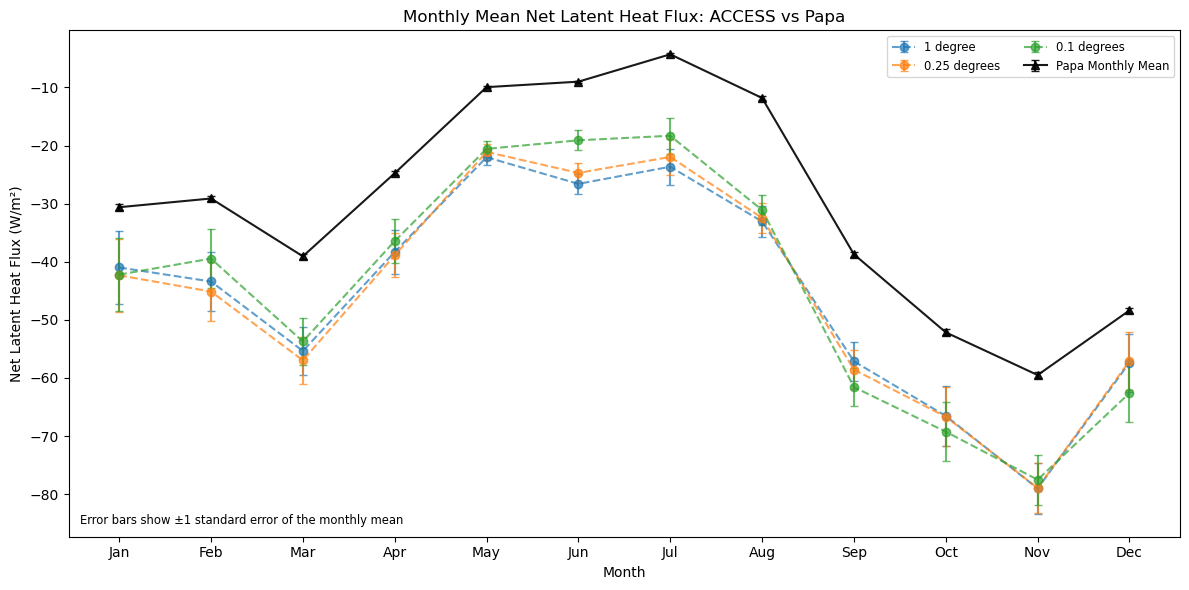

In [29]:
#----------------------------------------------------------------------------------------------
# PLOT
#----------------------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12,6))

exp_titles = {
    '1deg_jra55_iaf_omip2_cycle6': '1 degree',
    '025deg_jra55_iaf_omip2_cycle6': '0.25 degrees',
    '01deg_jra55v140_iaf_cycle4': '0.1 degrees'
}

for exp_name, data_dict in exp_heat_flux.items():
    monthly_mean = data_dict['monthly_mean']
    monthly_std  = data_dict['Monthly_std']
    label = exp_titles.get(exp_name, exp_name)

    ax.errorbar(
        monthly_mean['month'],
        monthly_mean.values,
        yerr=monthly_sem.values,
        marker='o',
        linestyle='--',
        alpha=0.7,
        capsize=3,
        label=label
    )

ax.errorbar(
    papa_monthly_mean['month'],
    -1 * papa_monthly_mean.values,
    yerr=papa_monthly_sem.values,
    color='black',
    marker='^',
    linestyle='-',
    alpha=0.9,
    capsize=3,
    label='Papa Monthly Mean'
)

ax.set_xlabel('Month')
ax.set_ylabel('Net Latent Heat Flux (W/m²)')
ax.set_title('Monthly Mean Net Latent Heat Flux: ACCESS vs Papa')
ax.set_xticks(np.arange(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend(ncol=2, fontsize='small', loc='best')
ax.text(
    0.01, 0.02,
    "Error bars show ±1 standard error of the monthly mean",
    transform=ax.transAxes,
    fontsize="small",
    ha="left",
    va="bottom"
)
plt.tight_layout()
plt.show()

In [23]:
# Pick one month to inspect (e.g., January = 1)
m = 1

print("PAPA mean Jan:", float(papa_monthly_mean.sel(month=m).values))
print("PAPA std  Jan:", float(papa_monthly_std.sel(month=m).values))

# Check one model experiment as well (use your exp key)
first_exp = list(exp_heat_flux.keys())[0]
print("MODEL mean Jan:", float(exp_heat_flux[first_exp]["monthly_mean"].sel(month=m).values))
print("MODEL std  Jan:", float(exp_heat_flux[first_exp]["Monthly_std"].sel(month=m).values))


PAPA mean Jan: 30.607059478759766
PAPA std  Jan: 45.56209945678711
MODEL mean Jan: -40.97848129272461
MODEL std  Jan: 20.871660232543945
